In [1]:
import ast, glob, warnings
import sys
from pathlib import Path
import numpy as np, pandas as pd, wfdb
import matplotlib.pyplot as plt
import scipy.signal
import torch, torch.nn as nn, torch.nn.functional as F
from scipy.signal import savgol_filter #smoothing windows
from torch.utils.data import Dataset, DataLoader


from sympy.strategies.core import switch

In [2]:
LUDB_ROOT = "../datasets/ludb/files/ludb/1.0.1/data"
ISP_ROOT  = "../datasets/ispdb"

PTB_ROOT   = "../datasets/ptbdb"
PTB_ANN    = f"{PTB_ROOT}/ptb_qt_annotations.csv"

LABELS = {0: "none", 1: "P", 2: "QRS", 3: "T"}
COLOR  = {1: "#e8b64c", 2: "#c1121f", 3: "#2a9d8f"}

TARGET_FS  = 500
WIN_SEC    = 10.0
LEN_5000   = int(TARGET_FS * WIN_SEC)      # U-Net, BeatSSL
LEN_2048   = 2048


In [3]:
def load_ludb(root=LUDB_ROOT, lead="ii"):
    out, skipped=[],[]
    #get hea files
    for hea in sorted(glob.glob(f"{root}/*.hea")):
        p=hea[:-4] #remove ".hea" name

        try:
            rec=wfdb.rdrecord(p)

            idx=[s.lower() for s in rec.sig_name].index(lead) #find lead index
            sig=rec.p_signal[:,idx].astype(np.float32)
            ann=wfdb.rdann(p,extension=lead) #raw

            #mask
            samples=ann.sample
            # print(len(sig))
            mask=np.zeros(len(sig),int)
            y=list(ann.symbol)
            i=0
            while i<len(y):
                if y[i]=="(" and i+2<len(y) and y[i+2]==")":
                    cls={"p":1,"N":2,"t":3}.get(y[i+1])
                    if cls:
                        mask[samples[i]:samples[i+2]+1]=cls
                        # print(samples[i])
                        # print(samples[i+2])
                        # print(mask[samples[i]:samples[i+2]])
                    i+=3
                else:
                    i+=1
                # print(mask)


            out.append({
                "id": f"ludb_{Path(p).name}",
                "path":p,
                "fs":int(rec.fs),
                "sig":sig,
                "sig12": rec.p_signal.astype(np.float32),
                "mask":mask,
                "ann":ann, #raw wfdb triples
                "leads":[s.lower() for s in rec.sig_name]
            })

        except Exception as e:
            skipped.append(f"{p} has problem as {e}")

    print(f"skipped: {len(skipped)}")
    print(f"loaded: {len(out)}")

    # for s in skipped: print("       ",s)
    return out


In [4]:
ISPMask={0:1,1:2,2:3}

def load_isp(root=ISP_ROOT,which="test",lead="ii"):
    csv=pd.read_csv(f"{root}/{which}_isp_delineation_data.csv")
    ann_col=next((c for c in csv.columns if str(csv[c].iloc[0]).strip().startswith("[(")),csv.columns[-1])
    out, skipped=[],[]

    for data,r in csv.iterrows():
        rid=str(r["file_name"])
        p=f"{root}/{which}_data/{rid}"
        # print(p)
        try:
            rec=wfdb.rdrecord(p)
            idx=[s.lower() for s in rec.sig_name].index(lead)
            sig=rec.p_signal.astype(np.float32)
            if np.nanmax(np.abs(sig))>50:
                sig=sig/1000.0
            # ann=wfdb.rdann(p,extension=lead)
            waves=ast.literal_eval(r[ann_col])
#             Evaluate an expression node or a string containing only a Python expression.

            #mask
            mask=np.zeros(len(sig),int)
            for cls, on ,off in waves:
                m=ISPMask.get(cls)
                if m:
                    mask[on:min(off+1,len(sig))] = m
                    # print(cls,on,off)
                    # print(mask[on])
                    # print(mask[off+1])
                    # print(mask[on:min(off+1,len(sig))])

            out.append({
                "id": f"ispdb_{Path(p).name}",
                "path":p,
                "fs":int(rec.fs),
                "sig":rec.p_signal[:,idx].astype(np.float32),
                "sig12": sig,
                "mask":mask,
                "waves":waves, #diff from ludb; raw(class,on,off)tuples
                "leads":[s.lower() for s in rec.sig_name]
            })

        except Exception as e:
            skipped.append(f"{p} has problem as {e}")

    print(f"skipped: {len(skipped)}")
    print(f"loaded: {len(out)}")

    for s in skipped: print("       ",s)
    return out

In [5]:

PTB_ROOT   = "../datasets/ptbdb"
PTB_ANN    = f"{PTB_ROOT}/ptb_qt_annotations.csv"

COLS  = ["patient","record","q1","q2","q3","q4","q5","q_med",
         "t1","t2","t3","t4","t5","t_med"]
QCOLS = ["q1","q2","q3","q4","q5"]
TCOLS = ["t1","t2","t3","t4","t5"]
NUM=COLS[2:]



In [6]:
ludb=load_ludb()
isp=load_isp(which="test")+load_isp(which="train")

skipped: 0
loaded: 200
skipped: 0
loaded: 72
skipped: 0
loaded: 403


In [7]:

# ludb check existing delineation
rows=[]
for r in ludb:
    m=r["mask"]
    for i, k in LABELS.items():
        rows.append({
            k: 100* (m==i).mean()
        }
        |
        {
            "beats":int((np.diff((m==2).astype(int)) == 1).sum())
        }
        )

df=pd.DataFrame(rows)
    # rows.append({
    #     k: 100 *(m==i).mean
    # })
print(df)

      none  beats      P    QRS      T
0    78.44      6    NaN    NaN    NaN
1      NaN      6   4.96    NaN    NaN
2      NaN      6    NaN   5.88    NaN
3      NaN      6    NaN    NaN  10.72
4    70.66      8    NaN    NaN    NaN
..     ...    ...    ...    ...    ...
795    NaN      8    NaN    NaN  10.24
796  60.22     12    NaN    NaN    NaN
797    NaN     12  10.12    NaN    NaN
798    NaN     12    NaN  10.22    NaN
799    NaN     12    NaN    NaN  19.44

[800 rows x 5 columns]


1749
[0.21783012 0.30025232 0.37342306 ... 0.11774601 0.11774601 0.11774601]
1749
[0.22870662 0.18454259 0.16876971 ... 0.48422712 0.4873817  0.48895898]
1749
[0.01742738 0.01742738 0.01742738 ... 0.26058092 0.25726141 0.25311204]
1749
[0.30330016 0.30330016 0.30330016 ... 0.00104767 0.00052384 0.        ]


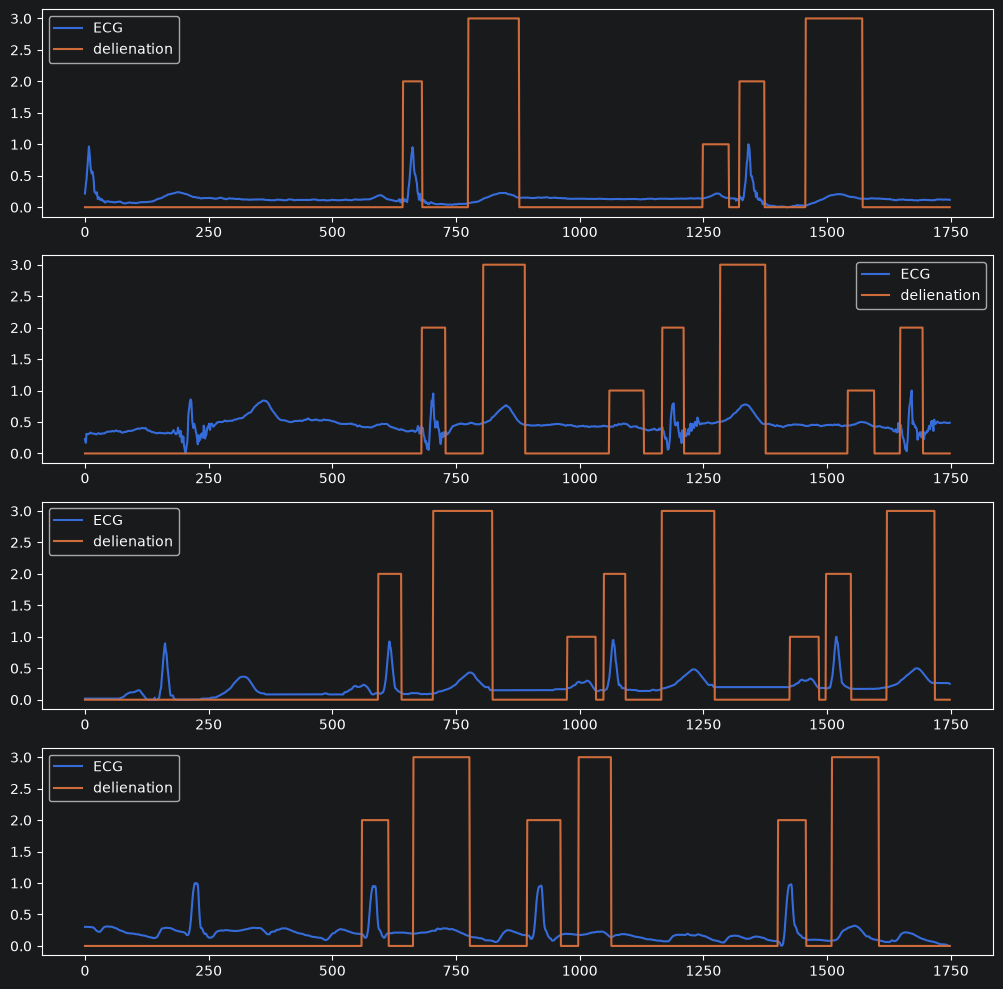

In [8]:

fig,axes=plt.subplots(4,1,figsize=(10,10))

for k in range(4):
    fs=ludb[k]["fs"]
    durationsig=2.5

    a= int(1) #start from 1s
    b=int(min((1+durationsig)*fs, len(ludb[k]["sig"])))

    sig=np.asarray(ludb[k]["sig"],float)[a:b]
    mask=np.asarray(ludb[k]["mask"],float)[a:b]

    ecgnormalized=(sig - sig.min()) / (np.ptp(sig)+1e-9) #peaktopeak

    print(len(ecgnormalized))
    print(ecgnormalized)

    axes[k].plot(np.arange(len(ecgnormalized)),ecgnormalized,label="ECG")
    axes[k].plot(mask,label="delienation")
    axes[k].legend()
plt.tight_layout()
plt.show()


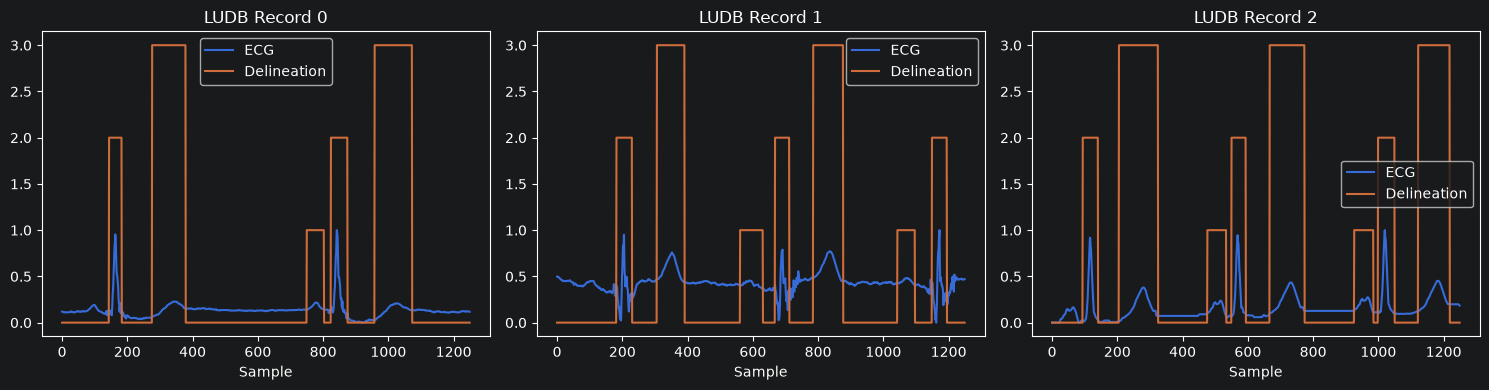

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for k in range(3):
    fs = ludb[k]["fs"]
    durationsig = 2.5

    a = int(1 * fs)  # start from 1 second
    b = int(min((1 + durationsig) * fs, len(ludb[k]["sig"])))

    sig = np.asarray(ludb[k]["sig"], float)[a:b]
    mask = np.asarray(ludb[k]["mask"], float)[a:b]

    # Normalize ECG to 0–1
    ecgnormalized = (sig - sig.min()) / (np.ptp(sig) + 1e-9)

    axes[k].plot(
        np.arange(len(ecgnormalized)),
        ecgnormalized,
        label="ECG"
    )
    axes[k].plot(mask, label="Delineation")

    axes[k].set_title(f"LUDB Record {k}")
    axes[k].set_xlabel("Sample")
    axes[k].legend()

plt.tight_layout()
plt.show()

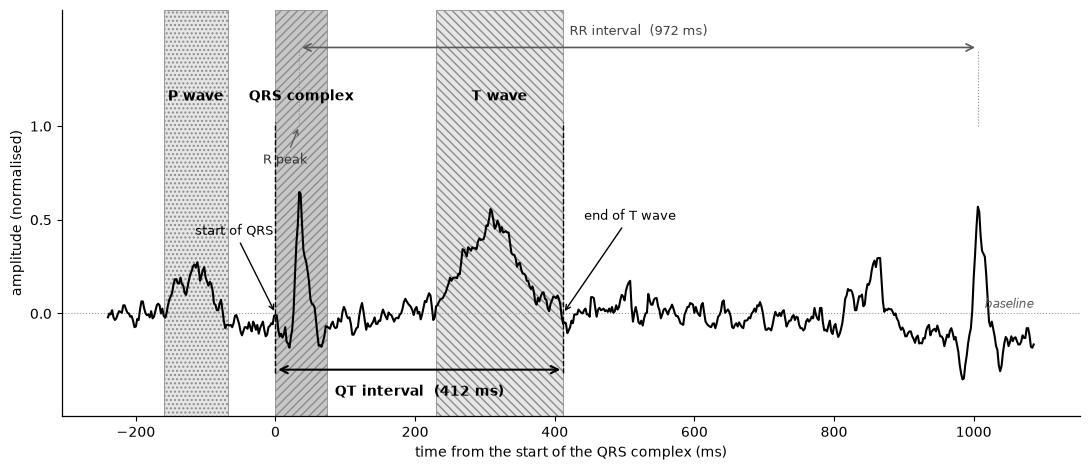

Figure 1.1 from LUDB record 103: QT 412 ms, RR 972 ms


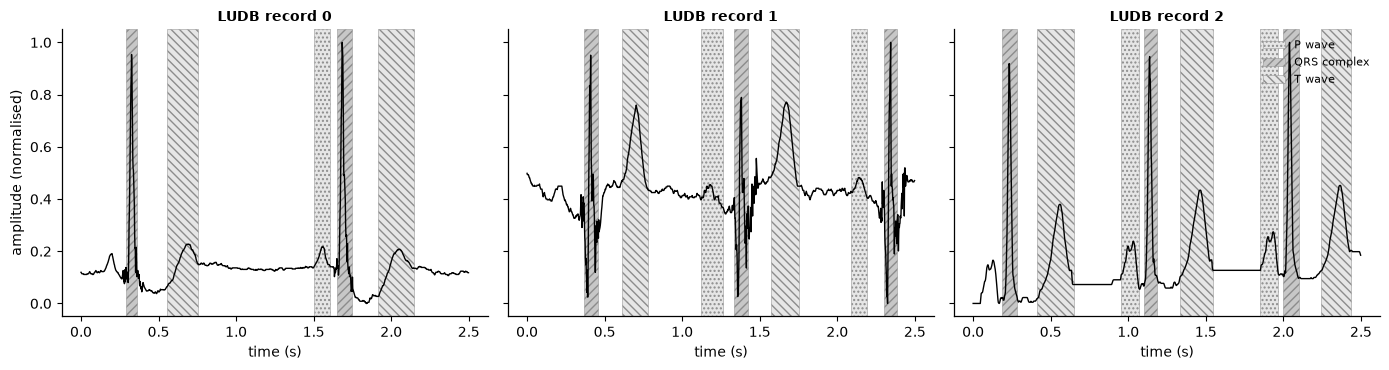

In [10]:


import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

plt.style.use("default")          # drop any dark notebook theme
plt.rcParams.update({
    "font.size": 10, "axes.linewidth": 0.9,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.edgecolor": "white",
    # every piece of text and every axis line, explicitly black
    "text.color": "black", "axes.labelcolor": "black",
    "axes.titlecolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black",
    "xtick.labelcolor": "black", "ytick.labelcolor": "black",
    "hatch.color": "0.55",
})

NAMES = {1: "P wave", 2: "QRS complex", 3: "T wave"}
FILL  = {1: "0.90", 2: "0.78", 3: "0.90"}
HATCH = {1: "....", 2: "////", 3: "\\\\\\\\"}


def blocks_of(m, val):
    """Contiguous [start, end] runs where mask == val."""
    idx = np.flatnonzero(np.asarray(m) == val)
    if idx.size == 0:
        return []
    cuts = np.flatnonzero(np.diff(idx) > 1)
    out, start = [], idx[0]
    for c in cuts:
        out.append((start, idx[c])); start = idx[c+1]
    out.append((start, idx[-1]))
    return out


def find_teaching_beat(recs):
    """A beat with P, QRS and T all present, a following QRS for the RR
    interval, and a reasonably tall T wave."""
    best = None
    for ri, rec in enumerate(recs):
        m = np.asarray(rec["mask"], int)
        sig = np.asarray(rec["sig"], float)
        P, Q, T = (blocks_of(m, v) for v in (1, 2, 3))
        if len(Q) < 2 or not P or not T:
            continue
        for qi in range(len(Q)-1):
            q0, q1 = Q[qi]
            p = [b for b in P if b[1] < q0 and q0-b[1] < 0.20*rec["fs"]]
            t = [b for b in T if b[0] > q1 and b[0]-q1 < 0.25*rec["fs"]]
            if not p or not t:
                continue
            t0, t1 = t[-1]
            if t1 >= Q[qi+1][0]:
                continue
            amp = np.ptp(sig[t0:t1+1])
            span = np.ptp(sig) + 1e-9
            score = amp/span
            if best is None or score > best[0]:
                best = (score, ri, p[-1], (q0, q1), (t0, t1), Q[qi+1])
    return best


# =========================================================================
# FIGURE 1.1
# =========================================================================
found = find_teaching_beat(ludb)
assert found is not None, "no suitable beat found"
_, ri, (p0, p1), (q0, q1), (t0, t1), (n0, n1) = found

rec = ludb[ri]
fs  = rec["fs"]
sig = np.asarray(rec["sig"], float)
m   = np.asarray(rec["mask"], int)

r_peak  = q0 + int(np.argmax(np.abs(sig[q0:q1+1])))
r_next  = n0 + int(np.argmax(np.abs(sig[n0:n1+1])))

pad = int(0.08*fs)
a   = max(0, p0 - pad)
b   = min(len(sig)-1, r_next + pad)

t_ms = (np.arange(a, b+1) - q0) * 1000.0 / fs      # zero at the QRS onset
y    = sig[a:b+1]
y    = (y - np.median(y[:pad])) / (np.ptp(sig[a:b+1]) + 1e-9)

fig, ax = plt.subplots(figsize=(11, 4.8))

for val, (s, e) in ((1, (p0, p1)), (2, (q0, q1)), (3, (t0, t1))):
    lo = (s - q0)*1000.0/fs
    hi = (e - q0)*1000.0/fs
    ax.axvspan(lo, hi, facecolor=FILL[val], edgecolor="0.55",
               hatch=HATCH[val], lw=0.6, zorder=0)
    ax.text((lo+hi)/2, 1.12, NAMES[val], ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="black")

ax.plot(t_ms, y, color="black", lw=1.5, zorder=3)
ax.axhline(0, color="0.6", lw=0.8, ls=":", zorder=1)
ax.text(t_ms[-1], 0.015, "baseline", ha="right", va="bottom",
        fontsize=8.5, color="0.35", style="italic")

qt_lo, qt_hi = 0.0, (t1 - q0)*1000.0/fs
rr_lo, rr_hi = (r_peak - q0)*1000.0/fs, (r_next - q0)*1000.0/fs

ax.add_patch(FancyArrowPatch((qt_lo, -0.30), (qt_hi, -0.30),
             arrowstyle="<->", mutation_scale=13, lw=1.5, color="black"))
ax.text((qt_lo+qt_hi)/2, -0.38, f"QT interval  ({qt_hi-qt_lo:.0f} ms)",
        ha="center", va="top", fontsize=10, fontweight="bold")
for xv in (qt_lo, qt_hi):
    ax.plot([xv, xv], [-0.32, 1.02], color="black", lw=1.0, ls="--", zorder=2)

ax.add_patch(FancyArrowPatch((rr_lo, 1.42), (rr_hi, 1.42),
             arrowstyle="<->", mutation_scale=13, lw=1.2, color="0.35"))
ax.text((rr_lo+rr_hi)/2, 1.47, f"RR interval  ({rr_hi-rr_lo:.0f} ms)",
        ha="center", va="bottom", fontsize=9.5, color="0.25")
for xv in (rr_lo, rr_hi):
    ax.plot([xv, xv], [1.0, 1.40], color="0.55", lw=0.8, ls=":", zorder=2)

ax.annotate("R peak", xy=(rr_lo, 1.0), xytext=(rr_lo-52, 0.80),
            fontsize=9, color="0.2",
            arrowprops=dict(arrowstyle="->", color="0.35", lw=0.9))
ax.annotate("start of QRS", xy=(qt_lo, 0.0), xytext=(qt_lo-115, 0.42),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0))
ax.annotate("end of T wave", xy=(qt_hi, 0.0), xytext=(qt_hi+30, 0.50),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0))

ax.set_xlabel("time from the start of the QRS complex (ms)")
ax.set_ylabel("amplitude (normalised)")
ax.set_ylim(-0.55, 1.62)
ax.set_yticks([0, 0.5, 1.0])
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("qt_anatomy.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure 1.1 from LUDB record {ri}: "
      f"QT {qt_hi-qt_lo:.0f} ms, RR {rr_hi-rr_lo:.0f} ms")


# =========================================================================
# FIGURE 3.x — your three-panel plot, fixed, for the Data chapter
# =========================================================================
# Changes: the mask goes on its own axis so it stops squashing the trace,
# it is drawn as a step function with named levels, and time is in seconds.

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for k, ax in enumerate(axes):
    rec = ludb[k]
    fs  = rec["fs"]
    a   = int(1.0*fs)
    b   = int(min((1.0 + 2.5)*fs, len(rec["sig"])))
    sig = np.asarray(rec["sig"], float)[a:b]
    msk = np.asarray(rec["mask"], int)[a:b]
    t   = np.arange(len(sig))/fs

    y = (sig - sig.min())/(np.ptp(sig) + 1e-9)
    ax.plot(t, y, color="black", lw=1.0, zorder=3)

    for val in (1, 2, 3):
        for s, e in blocks_of(msk, val):
            ax.axvspan(t[s], t[e], facecolor=FILL[val], edgecolor="0.6",
                       hatch=HATCH[val], lw=0.4, zorder=0)

    ax.set_title(f"LUDB record {k}", fontsize=10, fontweight="bold",
                 color="black")
    ax.set_xlabel("time (s)", color="black")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylabel("amplitude (normalised)")
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=FILL[v], edgecolor="0.6",
                         hatch=HATCH[v], lw=0.4) for v in (1, 2, 3)]
leg = axes[2].legend(handles, [NAMES[v] for v in (1, 2, 3)],
                     loc="upper right", fontsize=8, frameon=False)
for txt in leg.get_texts():
    txt.set_color("black")
plt.tight_layout()
plt.savefig("ludb_masks.png", dpi=300, bbox_inches="tight")
plt.show()

reference QTc over 198 LUDB records: median 418 ms, range 332-554
chosen: normal record 49 at 400 ms, prolonged record 122 at 554 ms


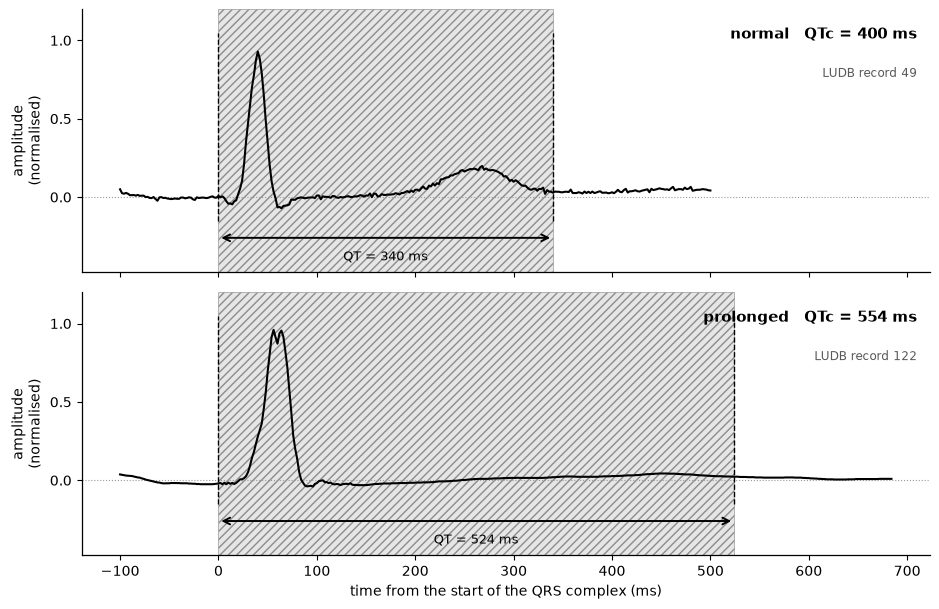

In [11]:
# =========================================================================
# FIGURE 1.2 — a normal record beside a prolonged one
#
# Run AFTER figure_1_1_anatomy.py, which defines blocks_of, NAMES, FILL,
# HATCH and the rcParams.
#
# Reference QTc is computed from the cardiologist mask, not from any model.
# =========================================================================

def record_qtc(rec):
    """Median Bazett QTc over the annotated beats of one record, in ms.
    Returns (qtc_ms, list of (q_start, t_end, r_peak))."""
    fs  = rec["fs"]
    sig = np.asarray(rec["sig"], float)
    m   = np.asarray(rec["mask"], int)
    Q, T = blocks_of(m, 2), blocks_of(m, 3)
    if len(Q) < 2 or not T:
        return np.nan, []

    rpk = [q0 + int(np.argmax(np.abs(sig[q0:q1+1]))) for q0, q1 in Q]
    beats, qtcs = [], []
    for i, (q0, q1) in enumerate(Q):
        t = [b for b in T if b[0] > q1 and b[0] - q1 < 0.25*fs]
        if not t:
            continue
        t_end = t[0][1]
        # RR from this R peak to the next, or the previous if there is none
        if i + 1 < len(rpk):
            rr = (rpk[i+1] - rpk[i]) / fs
        elif i > 0:
            rr = (rpk[i] - rpk[i-1]) / fs
        else:
            continue
        if not (0.3 < rr < 2.0):
            continue
        qt = (t_end - q0) * 1000.0 / fs
        qtcs.append(qt / np.sqrt(rr))
        beats.append((q0, t_end, rpk[i]))
    if not qtcs:
        return np.nan, []
    return float(np.median(qtcs)), beats


# ---- score every LUDB record -------------------------------------------
scored = []
for i, rec in enumerate(ludb):
    v, beats = record_qtc(rec)
    if np.isfinite(v) and beats:
        scored.append((v, i, beats))
scored.sort()

vals = np.array([s[0] for s in scored])
print(f"reference QTc over {len(scored)} LUDB records: "
      f"median {np.median(vals):.0f} ms, range {vals.min():.0f}-{vals.max():.0f}")

# normal: closest to 400 ms.  prolonged: the longest available.
normal = min(scored, key=lambda s: abs(s[0] - 400))
longqt = scored[-1]
print(f"chosen: normal record {normal[1]} at {normal[0]:.0f} ms, "
      f"prolonged record {longqt[1]} at {longqt[0]:.0f} ms")


def pick_beat(rec, beats, target_qtc):
    """The beat whose own QT is closest to the record median."""
    fs = rec["fs"]
    med = np.median([(t - q)*1000.0/fs for q, t, _ in beats])
    return min(beats, key=lambda b: abs((b[1]-b[0])*1000.0/fs - med))


# ---- plot ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True)

for ax, (qtc_val, ri, beats), label in zip(
        axes, (normal, longqt), ("normal", "prolonged")):

    rec = ludb[ri]
    fs  = rec["fs"]
    sig = np.asarray(rec["sig"], float)
    q0, t_end, rpk = pick_beat(rec, beats, qtc_val)

    a = max(0, q0 - int(0.10*fs))
    b = min(len(sig)-1, t_end + int(0.16*fs))
    t_ms = (np.arange(a, b+1) - q0) * 1000.0 / fs
    y = sig[a:b+1]
    y = (y - np.median(y[:int(0.06*fs)])) / (np.ptp(y) + 1e-9)

    qt_ms = (t_end - q0) * 1000.0 / fs

    ax.axvspan(0, qt_ms, facecolor="0.90", edgecolor="0.6",
               hatch="////", lw=0.5, zorder=0)
    ax.plot(t_ms, y, color="black", lw=1.5, zorder=3)
    ax.axhline(0, color="0.6", lw=0.8, ls=":", zorder=1)
    for xv in (0, qt_ms):
        ax.plot([xv, xv], [-0.15, 1.05], color="black", lw=1.0,
                ls="--", zorder=2)

    ax.add_patch(FancyArrowPatch((0, -0.26), (qt_ms, -0.26),
                 arrowstyle="<->", mutation_scale=12, lw=1.4, color="black"))
    ax.text(qt_ms/2, -0.34, f"QT = {qt_ms:.0f} ms",
            ha="center", va="top", fontsize=9.5, color="black")

    ax.text(0.985, 0.93, f"{label}   QTc = {qtc_val:.0f} ms",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10.5, fontweight="bold", color="black")
    ax.text(0.985, 0.78, f"LUDB record {ri}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8.5, color="0.35")

    ax.set_ylim(-0.48, 1.20)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_ylabel("amplitude\n(normalised)", color="black")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[1].set_xlabel("time from the start of the QRS complex (ms)", color="black")
plt.tight_layout()
plt.savefig( "qt_normal_vs_long.png", dpi=300, bbox_inches="tight")
plt.show()

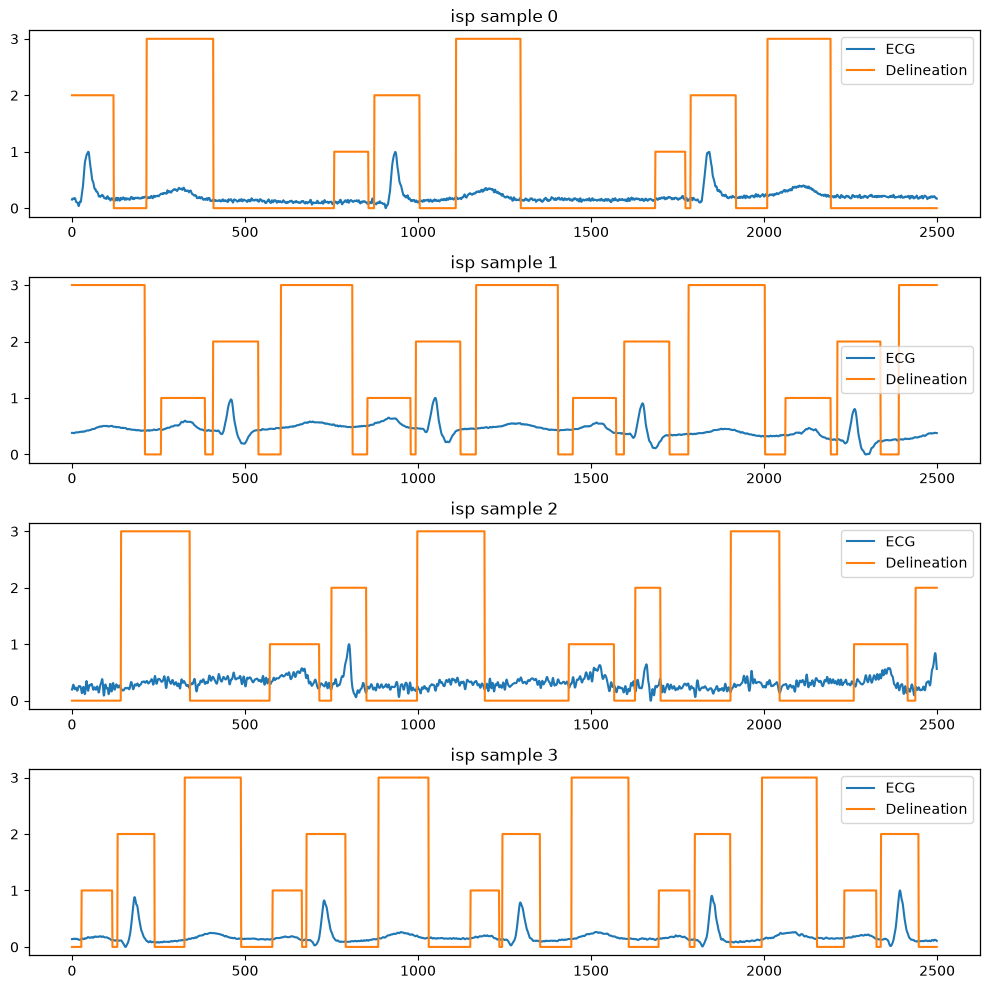

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

for k in range(4):
    fs = isp[k]["fs"]
    durationsig = 2.5

    a = int(0.4 * fs)
    b = int(min((0.4 + durationsig) * fs, len(ludb[k]["sig"])))

    sig = np.asarray(isp[k]["sig"], float)[a:b]
    mask = np.asarray(isp[k]["mask"], float)[a:b]

    ecgnormalized = (sig - sig.min()) / (np.ptp(sig) + 1e-9)

    axes[k].plot(
        np.arange(len(ecgnormalized)),
        ecgnormalized,
        label="ECG"
    )

    axes[k].plot(mask, label="Delineation")
    axes[k].legend()
    axes[k].set_title(f"isp sample {k}")

plt.tight_layout()
plt.show()

In [13]:
print(ludb[0]["leads"])

['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


In [14]:

def ptb_annotations():
    """The five reader marks per record, from the CSV alone. No waveforms."""
    csv = pd.read_csv(PTB_ANN, header=None, dtype=str)
    csv.columns = COLS
    for c in NUM:
        csv[c] = pd.to_numeric(
            csv[c].astype(str).str.replace(r"[^\d.\-]", "", regex=True),
            errors="coerce")
    ann = csv[csv[NUM].notna().sum(axis=1) >= 10].copy()
    ann["record"] = ann["record"].astype(str).str.strip()
    return ann


def ptb_reader_agreement(verbose=True):
    """Median standard deviation across five readers, in milliseconds.

    PTB is sampled at 1000 Hz, so one sample is one millisecond. This needs
    no waveform files, so it works even if the record loader finds nothing.
    """
    ann = ptb_annotations()
    q  = ann[QCOLS].to_numpy(float)
    t  = ann[TCOLS].to_numpy(float)
    qt = t - q
    sd_q, sd_t, sd_qt = (np.nanstd(x, axis=1, ddof=1) for x in (q, t, qt))
    out = {"n": len(ann),
           "qrs_onset_sd": float(np.nanmedian(sd_q)),
           "t_offset_sd":  float(np.nanmedian(sd_t)),
           "qt_sd":        float(np.nanmedian(sd_qt))}
    if verbose:
        print(f"  records with five reader marks: {out['n']}")
        print(f"  QRS onset   median SD {out['qrs_onset_sd']:5.2f} ms")
        print(f"  T offset    median SD {out['t_offset_sd']:5.2f} ms")
        print(f"  QT interval median SD {out['qt_sd']:5.2f} ms   <- the floor")
    return out


def load_ptb(root=PTB_ROOT, lead="ii", verbose=True):
    """PTB records with the median reader marks attached.

    Three bugs in the original are fixed here:
      1. the header lookup was rebuilt inside the file loop, so only the
         last .hea survived and 549 records became "loaded: 0";
      2. np.array(r[c] for c in QCOLS) built a 0-d object array from a
         generator, which is why np.isfinite refused it;
      3. it referenced an undefined `ann` when building a mask, but PTB has
         no per-sample annotation to build one from.
    """
    ann = ptb_annotations()

    lookup = {}                                   # built ONCE, outside the loop
    for h in sorted(glob.glob(f"{root}/**/*.hea", recursive=True)):
        lookup[Path(h).stem] = h[:-4]
    if verbose:
        print(f"  header files found: {len(lookup)}")

    norm = lambda s: str(s).strip().lower().replace("_", "").replace("-", "")
    lookup_n = {norm(k): v for k, v in lookup.items()}
    ann["rec_path"] = ann["record"].map(lambda s: lookup_n.get(norm(s)))
    matched = ann.dropna(subset=["rec_path"]).reset_index(drop=True)
    if verbose:
        print(f"  annotation rows matched to a file: {len(matched)} of {len(ann)}")

    out, skipped = [], []
    for _, r in matched.iterrows():
        pth = str(r["rec_path"])
        try:
            rec = wfdb.rdrecord(pth)
            names = [s.lower() for s in rec.sig_name]
            if lead not in names:
                skipped.append(f"{pth}: no lead {lead}"); continue
            sig = np.asarray(rec.p_signal[:, names.index(lead)], dtype=np.float32)

            # float arrays, not generators
            q = np.array([r[c] for c in QCOLS], dtype=float)
            t = np.array([r[c] for c in TCOLS], dtype=float)
            ok = np.isfinite(q) & np.isfinite(t) & (t > q)
            if ok.sum() < 2:
                skipped.append(f"{pth}: fewer than two usable reader marks"); continue

            out.append({
                "id":    f"ptbdb_{Path(pth).name}",
                "path":  pth,
                "fs":    int(rec.fs),
                "sig":   sig,
                "sig12": np.asarray(rec.p_signal, dtype=np.float32),
                "q_ref": float(np.median(q[ok])),   # gt_fiducials reads these
                "t_ref": float(np.median(t[ok])),
                "sd_qt": float(np.nanstd((t - q)[ok], ddof=1)),
                "leads": names,
            })
        except Exception as e:
            skipped.append(f"{pth}: {type(e).__name__}: {e}")

    if verbose:
        print(f"  loaded {len(out)}, skipped {len(skipped)}")
    return out


In [15]:
ptb=load_ptb()

  header files found: 549
  annotation rows matched to a file: 549 of 550
  loaded 548, skipped 1


In [16]:
print(ptb)

[{'id': 'ptbdb_s0010_re', 'path': '../datasets/ptbdb/files/ptbdb/1.0.0/patient001/s0010_re', 'fs': 1000, 'sig': array([-0.229 , -0.2335, -0.2345, ...,  0.2695,  0.256 ,  0.2585],
      shape=(38400,), dtype=float32), 'sig12': array([[-0.2445, -0.229 ,  0.0155, ..., -0.0015,  0.06  , -0.009 ],
       [-0.2425, -0.2335,  0.009 , ..., -0.0015,  0.061 , -0.01  ],
       [-0.2415, -0.2345,  0.007 , ..., -0.0035,  0.0555, -0.0085],
       ...,
       [ 0.152 ,  0.2695,  0.118 , ...,  0.079 ,  0.036 ,  0.031 ],
       [ 0.136 ,  0.256 ,  0.1205, ...,  0.081 ,  0.042 ,  0.03  ],
       [ 0.135 ,  0.2585,  0.1245, ...,  0.081 ,  0.049 ,  0.029 ]],
      shape=(38400, 15), dtype=float32), 'q_ref': 1340.0, 't_ref': 1755.0, 'sd_qt': 20.700241544484452, 'leads': ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'vx', 'vy', 'vz']}, {'id': 'ptbdb_s0014lre', 'path': '../datasets/ptbdb/files/ptbdb/1.0.0/patient001/s0014lre', 'fs': 1000, 'sig': array([-0.0595, -0.032 , -0.0345,

In [14]:
plt.show()
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

for k in range(4):
    fs = ptb[k]["fs"]
    durationsig = 2.5

    a = int(0.4 * fs)
    b = int(min((0.4 + durationsig) * fs, len(ludb[k]["sig"])))

    sig = np.asarray(isp[k]["sig"], float)[a:b]
    mask = np.asarray(isp[k]["mask"], float)[a:b]

    ecgnormalized = (sig - sig.min()) / (np.ptp(sig) + 1e-9)

    axes[k].plot(
        np.arange(len(ecgnormalized)),
        ecgnormalized,
        label="ECG"
    )

    axes[k].plot(mask, label="Delineation")
    axes[k].legend()
    axes[k].set_title(f"isp sample {k}")

plt.tight_layout()
plt.show()

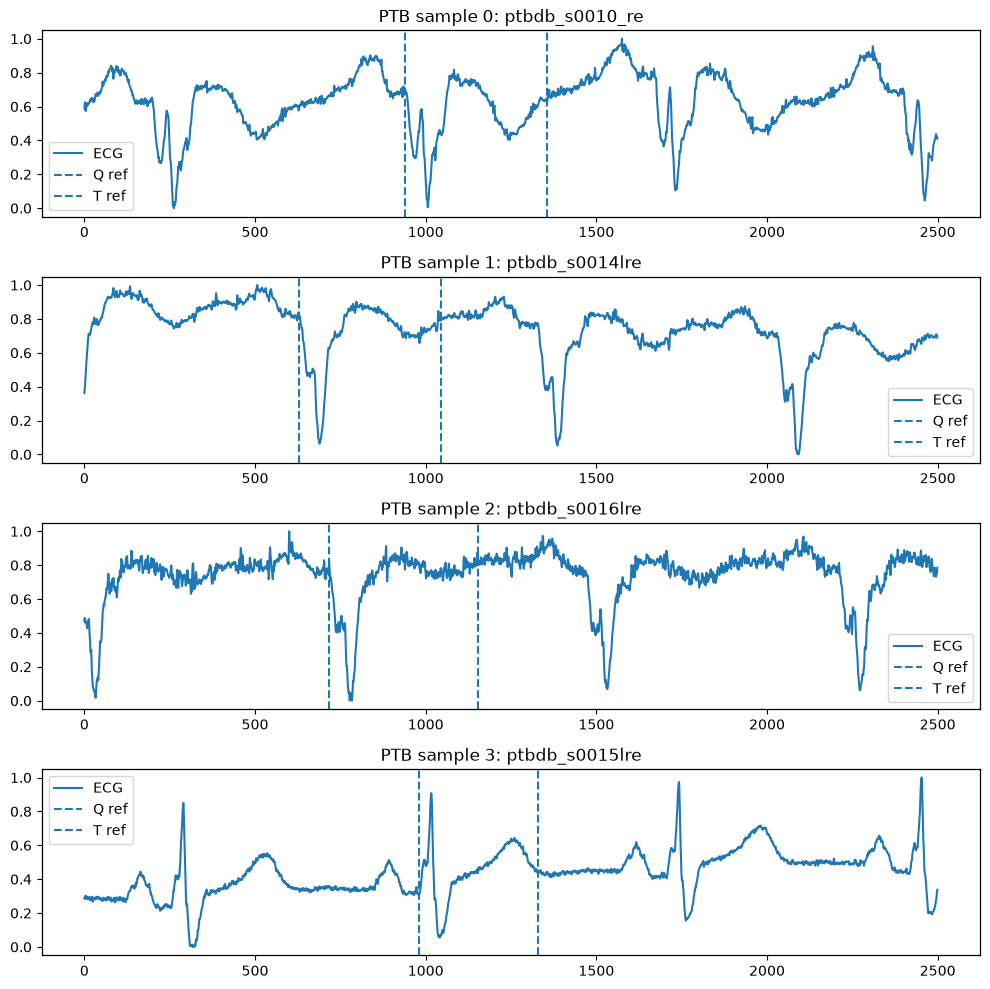

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

for k in range(4):
    fs = ptb[k]["fs"]
    durationsig = 2.5

    a = int(0.4 * fs)
    b = int(min((0.4 + durationsig) * fs, len(ptb[k]["sig"])))

    sig = np.asarray(ptb[k]["sig"], float)[a:b]

    q_ref = int(ptb[k]["q_ref"])
    t_ref = int(ptb[k]["t_ref"])

    # Normalize ECG
    ecgnormalized = (sig - sig.min()) / (np.ptp(sig) + 1e-9)

    axes[k].plot(
        np.arange(len(ecgnormalized)),
        ecgnormalized,
        label="ECG"
    )

    q_local = q_ref - a
    t_local = t_ref - a

    # Plot Q reference
    if 0 <= q_local < len(sig):
        axes[k].axvline(
            q_local,
            linestyle="--",
            label="Q ref"
        )

    # Plot T reference
    if 0 <= t_local < len(sig):
        axes[k].axvline(
            t_local,
            linestyle="--",
            label="T ref"
        )

    axes[k].legend()
    axes[k].set_title(f"PTB sample {k}: {ptb[k]['id']}")

plt.tight_layout()
plt.show()